# yz slab reader — single-variable test

Test the new sequential slab-based yz reader on **R1P1** (Nx=1536, light case).

Goal: read one yz slice for one variable (`u`), verify it looks sensible, time new vs old reader.

In [10]:
import sys, time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace
from pathlib import Path

import importlib
import utils_yz as utils
importlib.reload(utils)

<module 'utils_yz' from '/autofs/nccs-svm1_home2/lefauve/git/INCITE/adrien/utils_yz.py'>

## 1 — Case parameters

In [16]:
CSV_PATH     = Path("params.csv")
PROJECT_ROOT = Path("/lustre/orion/cfd135/proj-shared/Hsst")

PARAMS_DF      = pd.read_csv(CSV_PATH, dtype={"tStamp": str})
PARAMS_BY_CASE = {str(row["name"]).strip(): row for _, row in PARAMS_DF.iterrows()}

def build_case(name):
    row = PARAMS_BY_CASE[name]
    nx  = int(float(row["Nx"]))
    Lx  = float(row["Lx"])
    p   = SimpleNamespace()
    p.name   = name
    p.tStamp = str(row["tStamp"]).strip()
    p.Nx = nx;      p.Ny = nx // 2;  p.Nz = nx // 4
    p.Lx = Lx;      p.Ly = Lx / 2;  p.Lz = Lx / 4
    p.dirPath = str(PROJECT_ROOT / name / "001_Final") + "/"
    return p

CASE  = "R1P7"
VAR   = "u"
p     = build_case(CASE)
x_idx = p.Nx // 2   # yz slice at mid-x

print(f"Case : {p.name}   tStamp={p.tStamp}")
print(f"Grid : Nx={p.Nx}  Ny={p.Ny}  Nz={p.Nz}")
print(f"File : {p.dirPath}{VAR}_{p.tStamp}")
print(f"yz slice at x_idx={x_idx}  — expected output shape: ({p.Ny}, {p.Nz})")

Case : R1P7   tStamp=28.989493
Grid : Nx=3072  Ny=1536  Nz=768
File : /lustre/orion/cfd135/proj-shared/Hsst/R1P7/001_Final/u_28.989493
yz slice at x_idx=1536  — expected output shape: (1536, 768)


## 2 — Memory budget

For R1P1: one z-slab = `(Nx+2) * Ny * 4` bytes ≈ 12 MB — the entire Nz=384 fits in one slab at the 8 GB default.  
For heavy cases (R8P7, R10P7) set `CHUNK_GB = floor(available_RAM / nproc) - 2`.

In [17]:
CHUNK_GB    = 8.0    # increase on large-RAM nodes

bytes_per_z = (p.Nx + 2) * p.Ny * 4
chunk_nz    = max(1, int(CHUNK_GB * 1024**3) // bytes_per_z)
total_slabs = -(-p.Nz // chunk_nz)
slab_mb     = bytes_per_z * min(chunk_nz, p.Nz) / 1024**2

print(f"bytes per z-plane : {bytes_per_z / 1024**2:.1f} MB")
print(f"chunk_nz          : {chunk_nz}  z-planes per slab")
print(f"slab size         : {slab_mb:.1f} MB")
print(f"total slabs       : {total_slabs}  (for Nz={p.Nz})")

bytes per z-plane : 18.0 MB
chunk_nz          : 454  z-planes per slab
slab size         : 8177.3 MB
total slabs       : 2  (for Nz=768)


## 3 — Read the yz slice (new slab reader)

In [18]:
field = utils.open_lazy_yz(VAR, p, yz_chunk_mem_gb=CHUNK_GB)
print(f"LazyFieldYZ shape (excl. padding): {field.shape}")

t0     = time.perf_counter()
yz_new = field.read_yz(x_idx=x_idx, stride=(1, 1, 1))
t_new  = time.perf_counter() - t0

print(f"Done in {t_new:.2f} s")
print(f"Shape  : {yz_new.shape}   dtype={yz_new.dtype}")
print(f"min={yz_new.min():.4f}  max={yz_new.max():.4f}  mean={yz_new.mean():.6f}")

LazyFieldYZ shape (excl. padding): (3072, 1536, 768)
Done in 117.78 s
Shape  : (1536, 768)   dtype=float32
min=-0.5124  max=0.7532  mean=0.000000


## 4 — Correctness check: new vs old (naive strided)

In [19]:
mm = field.mm

t0     = time.perf_counter()
yz_old = np.asarray(mm[x_idx:x_idx+1, :p.Ny, :p.Nz][0, :, :])
t_old  = time.perf_counter() - t0

match = np.allclose(yz_new, yz_old, atol=0, rtol=0)

print(f"Old (naive strided) : {t_old*1000:.1f} ms")
print(f"New (slab reader)   : {t_new*1000:.1f} ms")
print(f"Values match        : {match}")
if not match:
    print(f"  max abs error: {np.max(np.abs(yz_new.astype(np.float64) - yz_old.astype(np.float64))):.2e}")

Old (naive strided) : 0.1 ms
New (slab reader)   : 117777.5 ms
Values match        : True


## 5 — Plot the slice

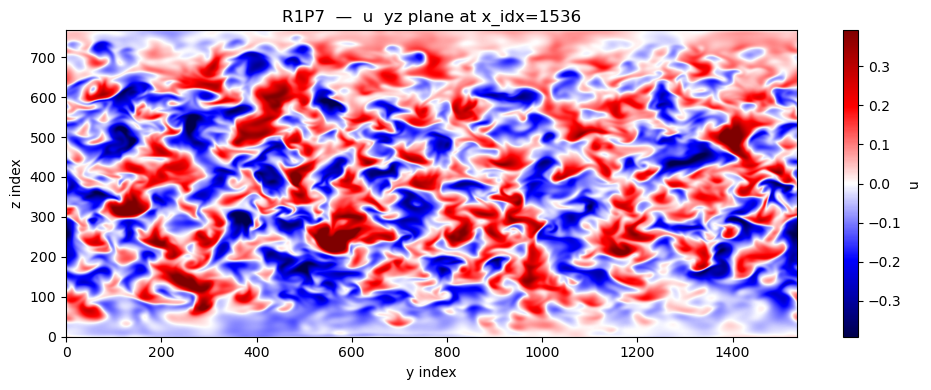

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
vlim = np.percentile(np.abs(yz_new), 99)
im = ax.imshow(yz_new.T, origin="lower", aspect="auto",
               cmap="seismic", vmin=-vlim, vmax=vlim)
ax.set_xlabel("y index")
ax.set_ylabel("z index")
ax.set_title(f"{CASE}  —  {VAR}  yz plane at x_idx={x_idx}")
plt.colorbar(im, ax=ax, label=VAR)
plt.tight_layout()
plt.show()

## 6 — All variables (uncomment once single-variable test passes)

In [23]:
VARS = ["u", "v", "w", "r", "ee", "chi"]
results = {}

for var in VARS:
    f  = utils.open_lazy_yz(var, p, yz_chunk_mem_gb=CHUNK_GB)
    t0 = time.perf_counter()
    results[var] = f.read_yz(x_idx=x_idx, stride=(1, 1, 1))
    elapsed = time.perf_counter() - t0
    print(f"{var:5s}  {elapsed:.2f} s  shape={results[var].shape}  "
          f"min={results[var].min():.3f}  max={results[var].max():.3f}")

u      1.81 s  shape=(1536, 768)  min=-0.512  max=0.753
v      111.19 s  shape=(1536, 768)  min=-0.540  max=0.409
w      115.21 s  shape=(1536, 768)  min=-0.491  max=0.454
r      106.16 s  shape=(1536, 768)  min=-0.001  max=0.001


KeyboardInterrupt: 

In [26]:
import time, numpy as np
import utils_yz

VAR_TEST = "ee"   # pick one not yet read
field_test = utils_yz.open_lazy_yz(VAR_TEST, p, yz_chunk_mem_gb=CHUNK_GB)
mm = field_test.mm

t0      = time.perf_counter()
yz_naive = np.asarray(mm[x_idx:x_idx+1, :p.Ny, :p.Nz][0, :, :])
t_naive  = time.perf_counter() - t0
print(f"Naive : {t_naive:.1f} s")

Naive : 0.0 s
